# CNN Predict — CESM2-LE JJA SST → September Slowdown

Loads **pre-computed CNN predictions** and reproduces the same figures as `cnn_train.ipynb` **without re-training or re-running inference**. Also generates composite maps of the SST input and LRP attributions for TP / FP / TN / FN scenarios.

**Prerequisites**
- `python scripts/04_cesm2le_cnn_train.py` — trains models and saves JSON histories
- `python scripts/05_cesm2le_lrp.py` — computes and saves LRP attributions
- `python scripts/06_cnn_predict_cesm2le.py` — precomputes predictions and saves to NetCDF

**Set `N_SPLITS` and `N_SEEDS` to match the values used during training, then Run All.**

In [ ]:
import sys
import json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.splits import load_tvt_split
from src.cnn.model  import METRIC_NAMES

# Standardize figure appearance for publication
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## Config
Must match the values used in `cnn_train.ipynb` (or `scripts/04_cesm2le_cnn_train.py`).

In [ ]:
# ── How many splits / seeds were trained ─────────────────────────────────────
N_SPLITS  = 9          # max 9
N_SEEDS   = 5          # random seeds per split
BASE_SEED = 42

# ── Dataset ───────────────────────────────────────────────────────────────────
BLOCK_SIZE = 10        # ensemble members per TVT block
START_YEAR = 1990      # first year in the loaded splits

METRICS_DIR    = paths.RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = paths.RESULTS_DIR / 'predictions' / 'cesm2le'

## Load loop
Loads TVT splits, **saved predictions**, metrics, training histories, and LRP attributions.
Results are stored in `results[split_idx]`.

In [ ]:
# results[split_idx] = {
#   'histories':     list[dict]        — one per seed (loaded from JSON)
#   'y_scores_runs': list[dict]        — one per seed, keys: train/val/test
#   'y_true':        dict              — keys: train/val/test
#   'thresholds':    list[float]       — one per seed (PR-curve optimal)
#   'ds_metrics':    xr.Dataset
#   'lrp_data':      list[dict|None]   — one per seed; None if LRP file missing
#   'sst_tr':        np.ndarray        — (n_tr, nx, ny) training SST
#   'lat':           np.ndarray        — (nlat,) 1-D latitude from LRP file
#   'lon':           np.ndarray        — (nlon,) 1-D longitude from LRP file
# }
results = {}

for split_idx in range(N_SPLITS):
    print(f'\n{"─"*60}')
    print(f'Split {split_idx}')
    print(f'{"─"*60}')

    # ── TVT split ─────────────────────────────────────────────────────────────
    split_path = paths.tvt_split_path(split_idx)
    if not split_path.exists():
        raise FileNotFoundError(
            f'TVT split not found: {split_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py first.'
        )
    split = load_tvt_split(split_path)

    y_tr = split['slow_tr']
    y_va = split['slow_va']
    y_te = split['slow_te']
    y_true = {'train': y_tr, 'val': y_va, 'test': y_te}

    print(f'  Train: {split["sst_tr"].shape}  prevalence={y_tr.mean():.3f}')
    print(f'  Val  : {split["sst_va"].shape}  prevalence={y_va.mean():.3f}')
    print(f'  Test : {split["sst_te"].shape}  prevalence={y_te.mean():.3f}')

    histories      = []
    y_scores_runs  = []
    thresholds     = []
    lrp_data       = []
    lat_shared     = None
    lon_shared     = None

    for run_idx in range(N_SEEDS):
        print(f'  seed {BASE_SEED + run_idx}: ', end='', flush=True)

        # ── Saved predictions ─────────────────────────────────────────────────
        pred_path = PREDICTIONS_DIR / f'cnn_prediction_cesm2le_M{split_idx}_{run_idx}.nc'
        if not pred_path.exists():
            raise FileNotFoundError(
                f'Prediction not found: {pred_path}\n'
                f'Run scripts/06_cnn_predict_cesm2le.py first.'
            )
        with xr.open_dataset(pred_path) as ds_pred:
            y_scores_runs.append({
                'train': ds_pred['y_prob_train'].values,
                'val':   ds_pred['y_prob_val'].values,
                'test':  ds_pred['y_prob_test'].values,
            })
            thresholds.append(float(ds_pred['threshold'].values))
        print('predictions ✓', end='  ', flush=True)

        # ── Training history ──────────────────────────────────────────────────
        hist_path = paths.LOGS_DIR / f'history_split{split_idx}_run{run_idx}.json'
        if hist_path.exists():
            with open(hist_path) as f:
                histories.append(json.load(f))
        else:
            histories.append(None)
            print(f'(history not found: {hist_path})', end='  ')
        print('history ✓', end='  ', flush=True)

        # ── LRP attributions ──────────────────────────────────────────────────
        lrp_path = paths.attribution_path(split_idx, run_idx)
        if lrp_path.exists():
            lrp_ds   = xr.open_dataset(lrp_path)
            lrp_raw  = lrp_ds['lrp_attributions'].values   # (n_chunks, chunk_size, nx, ny, 1)
            lat_1d   = lrp_ds['lat'].values                 # (nx,)
            lon_1d   = lrp_ds['lon'].values                 # (ny,)
            lrp_ds.close()
            # flatten to (n_lrp, nx, ny)
            lrp_flat = lrp_raw.reshape(-1, lrp_raw.shape[2], lrp_raw.shape[3])
            lrp_data.append({'lrp_flat': lrp_flat})
            if lat_shared is None:
                lat_shared = lat_1d
                lon_shared = lon_1d
            print('LRP ✓')
        else:
            lrp_data.append(None)
            print(f'(LRP not found: {lrp_path})')

    # ── Metrics dataset ───────────────────────────────────────────────────────
    metrics_p = paths.metrics_path(split_idx)
    if not metrics_p.exists():
        raise FileNotFoundError(
            f'Metrics not found: {metrics_p}\n'
            f'Run scripts/04_cesm2le_cnn_train.py first.'
        )
    ds_metrics = xr.open_dataset(metrics_p)

    results[split_idx] = {
        'histories':     histories,
        'y_scores_runs': y_scores_runs,
        'y_true':        y_true,
        'thresholds':    thresholds,
        'ds_metrics':    ds_metrics,
        'lrp_data':      lrp_data,
        'sst_tr':        split['sst_tr'],   # (n_tr, nx, ny) — no channel dim
        'lat':           lat_shared,
        'lon':           lon_shared,
    }

print('\nLoading complete.')

---
## Composite Maps

For each selected scenario (TP / FP / TN / FN):
- **(a)** Mean JJA SST input over all scenario samples (land masked to NaN)
- **(b)** Mean LRP attribution over all scenario samples

Composites are computed per split × seed first, then averaged across all splits × seeds.

> **Note:** LRP must have been computed with `scripts/05_cesm2le_lrp.py`. Splits/seeds missing LRP files are automatically skipped.

In [4]:
# ── Toggle scenarios to plot ──────────────────────────────────────────────────
SHOW_TP = True
SHOW_FP = False
SHOW_TN = False
SHOW_FN = False

In [ ]:
SCENARIO_FLAGS = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
ACTIVE_SCENARIOS = [k for k, v in SCENARIO_FLAGS.items() if v]

for scenario_name in ACTIVE_SCENARIOS:

    sst_per_sr = []
    lrp_per_sr = []
    lat_plot   = None
    lon_plot   = None

    for split_idx in range(N_SPLITS):
        res    = results[split_idx]
        sst_tr = res['sst_tr']   # (n_tr, nx, ny)

        for run_idx in range(N_SEEDS):
            lrp_info = res['lrp_data'][run_idx]
            if lrp_info is None:
                continue   # LRP not available for this split/seed

            y_s = res['y_scores_runs'][run_idx]['train']
            y_t = res['y_true']['train']

            # ── threshold (from saved predictions) ────────────────────────────
            thr_best = res['thresholds'][run_idx]
            y_pred   = (y_s >= thr_best).astype(int)

            # ── scenario mask ─────────────────────────────────────────────────
            if scenario_name == 'TP':
                mask = (y_pred == 1) & (y_t == 1)
            elif scenario_name == 'FP':
                mask = (y_pred == 1) & (y_t == 0)
            elif scenario_name == 'TN':
                mask = (y_pred == 0) & (y_t == 0)
            else:   # FN
                mask = (y_pred == 0) & (y_t == 1)

            # ── align LRP with training data (LRP may have fewer samples) ────
            lrp_flat = lrp_info['lrp_flat']   # (n_lrp, nx, ny)
            n_lrp    = lrp_flat.shape[0]
            mask_lrp = mask[:n_lrp]
            sst_lrp  = sst_tr[:n_lrp]         # (n_lrp, nx, ny)

            if mask_lrp.sum() == 0:
                continue

            # ── SST composite — land fill (-10) → NaN ────────────────────────
            sst_masked = sst_lrp.astype(float).copy()
            sst_masked[sst_masked < -5] = np.nan
            sst_mean = np.nanmean(sst_masked[mask_lrp], axis=0)   # (nx, ny)

            # ── LRP composite ────────────────────────────────────────────────
            lrp_mean = np.mean(lrp_flat[mask_lrp], axis=0)        # (nx, ny)

            sst_per_sr.append(sst_mean)
            lrp_per_sr.append(lrp_mean)

            if lat_plot is None:
                lat_plot = res['lat']
                lon_plot = res['lon']

    if len(sst_per_sr) == 0:
        print(f'{scenario_name}: no samples found across any split/seed — skipping.')
        continue

    n_sr      = len(sst_per_sr)
    sst_grand = np.nanmean(np.stack(sst_per_sr, axis=0), axis=0)  # (nx, ny)
    lrp_grand = np.nanmean(np.stack(lrp_per_sr, axis=0), axis=0)  # (nx, ny)

    # ── 97th-percentile normalization (signed → [-1, 1]) ─────────────────────
    sst_scale = np.nanpercentile(np.abs(sst_grand), 97)
    sst_grand = np.clip(sst_grand / (sst_scale + 1e-12), -1, 1)
    lrp_scale = np.nanpercentile(np.abs(lrp_grand), 97)
    lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), -1, 1)

    print(f'{scenario_name}: averaged over {n_sr} split×seed composites')

    # ── Build 2-D lat/lon grid for plotting ───────────────────────────────────
    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)   # (nlat, nlon)

    # ── Figure ────────────────────────────────────────────────────────────────
    proj  = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(14, 5))
    ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
    ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

    for ax, data, vmin, vmax, cmap, title, cbar_label in [
        (ax_sst, sst_grand, -1, 1, cmocean.cm.balance, '(a)', 'SST (normalized)'),
        (ax_lrp, lrp_grand, -1, 1, cmocean.cm.curl, '(b)', 'Relevance (normalized)'),
    ]:
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
        ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

        im = ax.pcolormesh(
            lon2d, lat2d, data,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            zorder=0,
        )
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                     fraction=0.046, label=cbar_label)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# plotting options
# ------------------------------------------------------------------
LRP_POSITIVE_ONLY = True   # False = signed relevance, True = keep only positive
LRP_POSITIVE_CMAP = 'magma'
LRP_SIGNED_CMAP   = cmocean.cm.curl

SCENARIO_FLAGS = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
ACTIVE_SCENARIOS = [k for k, v in SCENARIO_FLAGS.items() if v]

for scenario_name in ACTIVE_SCENARIOS:

    sst_per_sr = []
    lrp_per_sr = []
    lat_plot   = None
    lon_plot   = None

    for split_idx in range(N_SPLITS):
        res    = results[split_idx]
        sst_tr = res['sst_tr']   # (n_tr, nx, ny)

        for run_idx in range(N_SEEDS):
            lrp_info = res['lrp_data'][run_idx]
            if lrp_info is None:
                continue

            y_s = res['y_scores_runs'][run_idx]['train']
            y_t = res['y_true']['train']

            # ── threshold (from saved predictions) ─────────────────────
            thr_best = res['thresholds'][run_idx]
            y_pred   = (y_s >= thr_best).astype(int)

            # ── scenario mask ──────────────────────────────────────────
            if scenario_name == 'TP':
                mask = (y_pred == 1) & (y_t == 1)
            elif scenario_name == 'FP':
                mask = (y_pred == 1) & (y_t == 0)
            elif scenario_name == 'TN':
                mask = (y_pred == 0) & (y_t == 0)
            else:   # FN
                mask = (y_pred == 0) & (y_t == 1)

            # ── align LRP with training data ───────────────────────────
            lrp_flat = lrp_info['lrp_flat']   # (n_lrp, nx, ny)
            n_lrp    = lrp_flat.shape[0]
            mask_lrp = mask[:n_lrp]
            sst_lrp  = sst_tr[:n_lrp]

            if mask_lrp.sum() == 0:
                continue

            # ── SST composite — land fill (-10) → NaN ─────────────────
            sst_masked = sst_lrp.astype(float).copy()
            sst_masked[sst_masked < -5] = np.nan
            sst_mean = np.nanmean(sst_masked[mask_lrp], axis=0)

            # ── LRP composite ──────────────────────────────────────────
            lrp_selected = lrp_flat[mask_lrp]

            if LRP_POSITIVE_ONLY:
                lrp_selected = np.where(lrp_selected > 0, lrp_selected, 0.0)

            lrp_mean = np.mean(lrp_selected, axis=0)

            sst_per_sr.append(sst_mean)
            lrp_per_sr.append(lrp_mean)

            if lat_plot is None:
                lat_plot = res['lat']
                lon_plot = res['lon']

    if len(sst_per_sr) == 0:
        print(f'{scenario_name}: no samples found across any split/seed — skipping.')
        continue

    n_sr      = len(sst_per_sr)
    sst_grand = np.nanmean(np.stack(sst_per_sr, axis=0), axis=0)
    lrp_grand = np.nanmean(np.stack(lrp_per_sr, axis=0), axis=0)

    # ── 97th-percentile normalization ─────────────────────────────────
    # SST: signed → [-1, 1]
    sst_scale = np.nanpercentile(np.abs(sst_grand), 97)
    sst_grand = np.clip(sst_grand / (sst_scale + 1e-12), -1, 1)
    # LRP: positive-only → [0, 1]
    lrp_scale = np.nanpercentile(lrp_grand, 97)
    lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), 0, 1)

    print(f'{scenario_name}: averaged over {n_sr} split×seed composites')

    # ── Build 2-D lat/lon grid for plotting ───────────────────────────
    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)

    # ── Figure ────────────────────────────────────────────────────────
    proj = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(14, 5))
    ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
    ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

    # SST panel
    ax_sst.set_global()
    ax_sst.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_sst.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
    ax_sst.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    im_sst = ax_sst.pcolormesh(
        lon2d, lat2d, sst_grand,
        cmap=cmocean.cm.balance,
        vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    plt.colorbar(im_sst, ax=ax_sst, orientation='horizontal', pad=0.04,
                 fraction=0.046, label='SST (normalized)')
    ax_sst.set_title('(a)')

    # LRP panel
    ax_lrp.set_global()
    ax_lrp.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_lrp.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
    ax_lrp.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    im_lrp = ax_lrp.pcolormesh(
        lon2d, lat2d, lrp_grand,
        cmap=LRP_POSITIVE_CMAP,
        vmin=0, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    plt.colorbar(im_lrp, ax=ax_lrp, orientation='horizontal', pad=0.04,
                 fraction=0.046, label='Relevance (normalized)')
    ax_lrp.set_title('(b)')

    plt.tight_layout()
    plt.show()

---
## ENSO-Indexed Composite Maps

For each selected scenario (TP / FP / TN / FN):
- **top row (a-c)** Mean JJA SST input over -/0/+ Nino Index scenario samples (land masked to NaN)
- **bottom row (d-f)** Mean LRP attribution over -/0/+ Nino Index scenario samples

Composites are computed per split × seed first, then averaged across all splits × seeds.

> **Note:** LRP must have been computed with `scripts/05_cesm2le_lrp.py`. Splits/seeds missing LRP files are automatically skipped.

In [ ]:
# ── Load split-aligned climate indices ────────────────────────────────────────
for split_idx in range(N_SPLITS):
    idx_path = paths.TVT_SPLITS_DIR / f'cesm2le_climate_indices_split{split_idx}.nc'
    if not idx_path.exists():
        raise FileNotFoundError(
            f'Climate index split not found: {idx_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py first.'
        )
    with xr.open_dataset(idx_path) as ds_idx:
        for vname in ds_idx.data_vars:
            results[split_idx][vname] = ds_idx[vname].values
print('Climate indices loaded for all splits.')

# ── Phase definitions (thresholds match src/data/cesm2le/climate_indices.py) ──
ENSO_PHASES = [
    ('\u2212', lambda x: x <= -0.4),
    ('0',      lambda x: (x > -0.4) & (x < 0.4)),
    ('+',      lambda x: x >= 0.4),
]
IPO_PHASES = [
    ('\u2212', lambda x: x <= 0),
    ('+',      lambda x: x > 0),
]
ARCTIC_PHASES = [
    ('\u2212', lambda x: x <= -1.0),
    ('0',      lambda x: (x > -1.0) & (x < 1.0)),
    ('+',      lambda x: x >= 1.0),
]

# ── Helper: scenario × phase composites ──────────────────────────────────────
def plot_index_composites(index_key, index_name, phase_defs, lrp_positive_only=False):
    """Composite maps conditioned on prediction scenario and climate-index phase."""
    SCENARIO_FLAGS_ = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
    active = [k for k, v in SCENARIO_FLAGS_.items() if v]
    if not active:
        print('No active scenarios — nothing to plot.')
        return

    n_phases = len(phase_defs)
    phase_labels = [p for p, _ in phase_defs]

    # Accumulate per split × seed
    comps = {s: {p: {'sst': [], 'lrp': []} for p in phase_labels} for s in active}
    lat_p = lon_p = None

    for si in range(N_SPLITS):
        res = results[si]
        sst_tr = res['sst_tr']
        idx_vals = res[index_key]       # (n_tr,) — aligned climate index

        for ri in range(N_SEEDS):
            lrp_info = res['lrp_data'][ri]
            if lrp_info is None:
                continue
            y_s = res['y_scores_runs'][ri]['train']
            y_t = res['y_true']['train']

            # Threshold from saved predictions
            thr_best = res['thresholds'][ri]
            y_pred = (y_s >= thr_best).astype(int)

            lrp_flat = lrp_info['lrp_flat']
            n_lrp = lrp_flat.shape[0]

            for sc in active:
                # Scenario mask (same logic as existing cells)
                if   sc == 'TP': smask = (y_pred == 1) & (y_t == 1)
                elif sc == 'FP': smask = (y_pred == 1) & (y_t == 0)
                elif sc == 'TN': smask = (y_pred == 0) & (y_t == 0)
                else:            smask = (y_pred == 0) & (y_t == 1)

                for plbl, pfunc in phase_defs:
                    # Intersect scenario mask with phase mask, aligned to LRP length
                    combined = smask[:n_lrp] & pfunc(idx_vals[:n_lrp])
                    if combined.sum() == 0:
                        continue

                    # SST composite (land fill → NaN)
                    sst_sub = sst_tr[:n_lrp].astype(float).copy()
                    sst_sub[sst_sub < -5] = np.nan
                    comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))

                    # LRP composite
                    lrp_sub = lrp_flat[combined]
                    if lrp_positive_only:
                        lrp_sub = np.where(lrp_sub > 0, lrp_sub, 0.0)
                    comps[sc][plbl]['lrp'].append(np.mean(lrp_sub, axis=0))

                    if lat_p is None:
                        lat_p, lon_p = res['lat'], res['lon']

    if lat_p is None:
        print('No composites computed — check data availability.')
        return

    # Grand average across split × seed composites
    for sc in active:
        for plbl in phase_labels:
            d = comps[sc][plbl]
            if d['sst']:
                d['sst_avg'] = np.nanmean(np.stack(d['sst']), axis=0)
                d['lrp_avg'] = np.nanmean(np.stack(d['lrp']), axis=0)
                d['n'] = len(d['sst'])
            else:
                d['sst_avg'] = d['lrp_avg'] = None
                d['n'] = 0

    # ── Global 97th-percentile normalization across ALL panels ────────────────
    all_sst_vals = []
    all_lrp_vals = []
    for sc in active:
        for plbl in phase_labels:
            d = comps[sc][plbl]
            if d['sst_avg'] is not None:
                all_sst_vals.append(d['sst_avg'])
                all_lrp_vals.append(d['lrp_avg'])

    if not all_sst_vals:
        print('No valid composites to normalize — skipping plot.')
        return

    all_sst_stack = np.stack(all_sst_vals)
    all_lrp_stack = np.stack(all_lrp_vals)

    sst_scale = np.nanpercentile(np.abs(all_sst_stack), 97)
    if lrp_positive_only:
        lrp_scale = np.nanpercentile(all_lrp_stack, 97)
    else:
        lrp_scale = np.nanpercentile(np.abs(all_lrp_stack), 97)

    # Normalize all panels with shared scale
    for sc in active:
        for plbl in phase_labels:
            d = comps[sc][plbl]
            if d['sst_avg'] is not None:
                d['sst_avg'] = np.clip(d['sst_avg'] / (sst_scale + 1e-12), -1, 1)
                if lrp_positive_only:
                    d['lrp_avg'] = np.clip(d['lrp_avg'] / (lrp_scale + 1e-12), 0, 1)
                else:
                    d['lrp_avg'] = np.clip(d['lrp_avg'] / (lrp_scale + 1e-12), -1, 1)

    # ── Plot ──────────────────────────────────────────────────────────────────
    lon2d, lat2d = np.meshgrid(lon_p, lat_p)
    proj = ccrs.PlateCarree(central_longitude=180)
    nrows = 2 * len(active)
    ncols = n_phases

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows),
                             subplot_kw={'projection': proj}, squeeze=False)

    # Generate panel labels (a), (b), (c), ...
    import string
    panel_idx = 0

    for si_idx, sc in enumerate(active):
        for pi, plbl in enumerate(phase_labels):
            d = comps[sc][plbl]
            for ri, (key, cbar_label, is_lrp) in enumerate([
                ('sst_avg', 'SST (normalized)', False),
                ('lrp_avg', 'Relevance (normalized)', True),
            ]):
                ax = axes[2 * si_idx + ri, pi]
                ax.set_global()
                ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
                ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
                ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

                data = d[key]
                letter = string.ascii_lowercase[panel_idx]
                panel_idx += 1

                if data is None:
                    ax.set_title(f'({letter})')
                    continue

                if not is_lrp:
                    im = ax.pcolormesh(lon2d, lat2d, data, cmap=cmocean.cm.balance,
                                       vmin=-1, vmax=1, transform=ccrs.PlateCarree(),
                                       shading='auto', zorder=0)
                    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                                 fraction=0.046, label=cbar_label)
                elif lrp_positive_only:
                    im = ax.pcolormesh(lon2d, lat2d, data, cmap='magma',
                                       vmin=0, vmax=1, transform=ccrs.PlateCarree(),
                                       shading='auto', zorder=0)
                    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                                 fraction=0.046, label=cbar_label)
                else:
                    im = ax.pcolormesh(lon2d, lat2d, data, cmap=cmocean.cm.curl,
                                       vmin=-1, vmax=1, transform=ccrs.PlateCarree(),
                                       shading='auto', zorder=0)
                    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                                 fraction=0.046, label=cbar_label)

                ax.set_title(f'({letter})')

    plt.tight_layout()
    plt.show()

# ── Figure: ENSO × signed LRP ────────────────────────────────────────────────
plot_index_composites('nino34_tr', 'Ni\u00f1o3.4', ENSO_PHASES, lrp_positive_only=False)

/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.

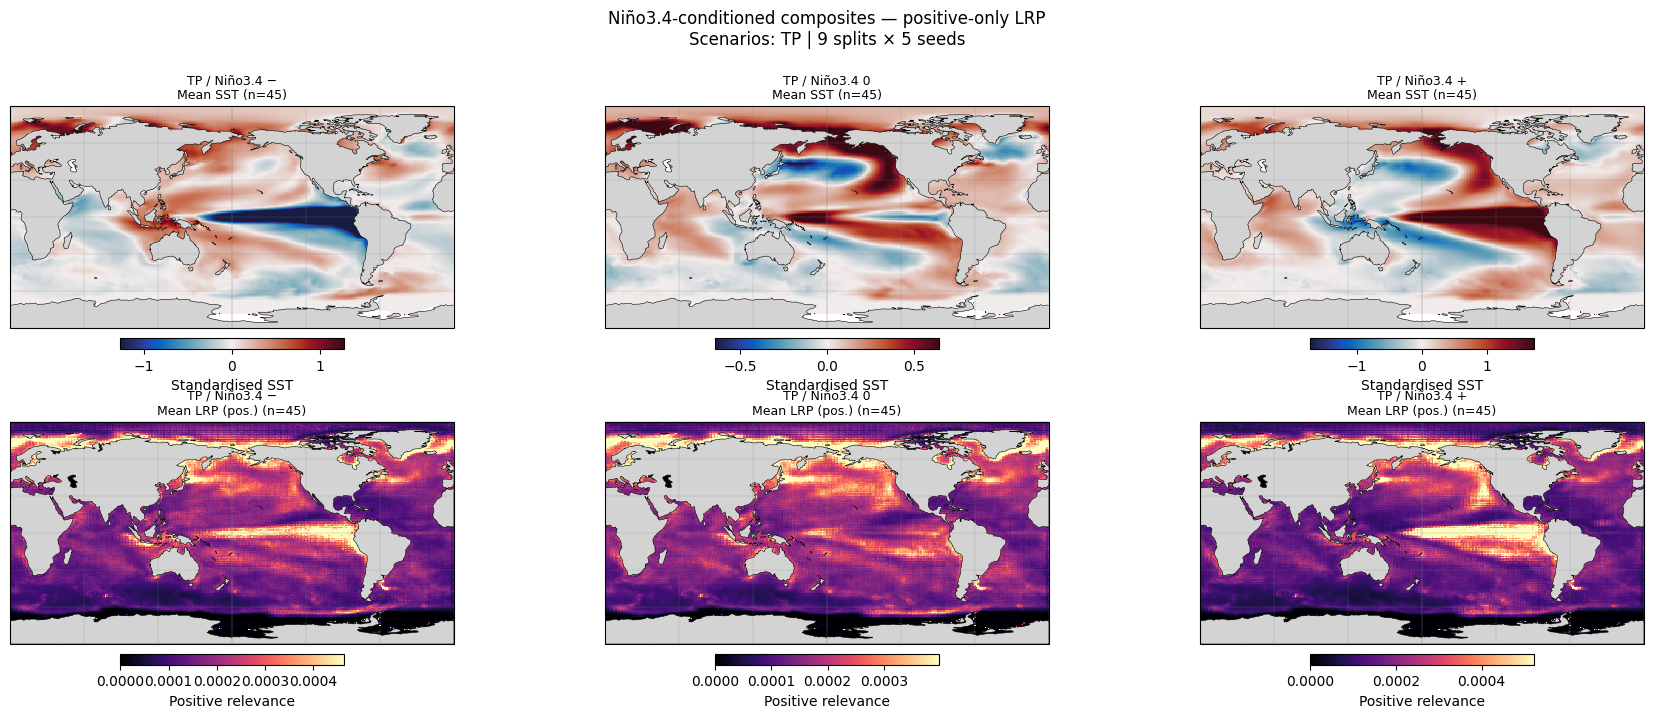

In [9]:
# ── Figure: ENSO × positive-only LRP ──────────────────────────────────────────
plot_index_composites('nino34_tr', 'Ni\u00f1o3.4', ENSO_PHASES, lrp_positive_only=True)


/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.

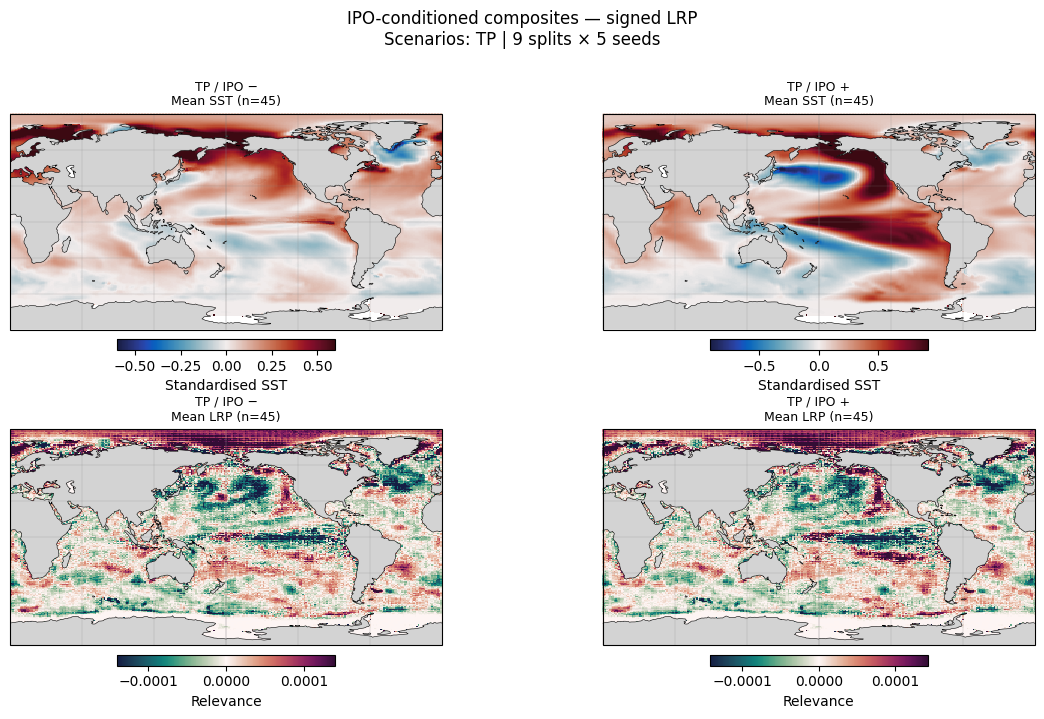

In [10]:
# ── Figure: IPO × signed LRP ──────────────────────────────────────────────────
plot_index_composites('ipo_tr', 'IPO', IPO_PHASES, lrp_positive_only=False)

/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.

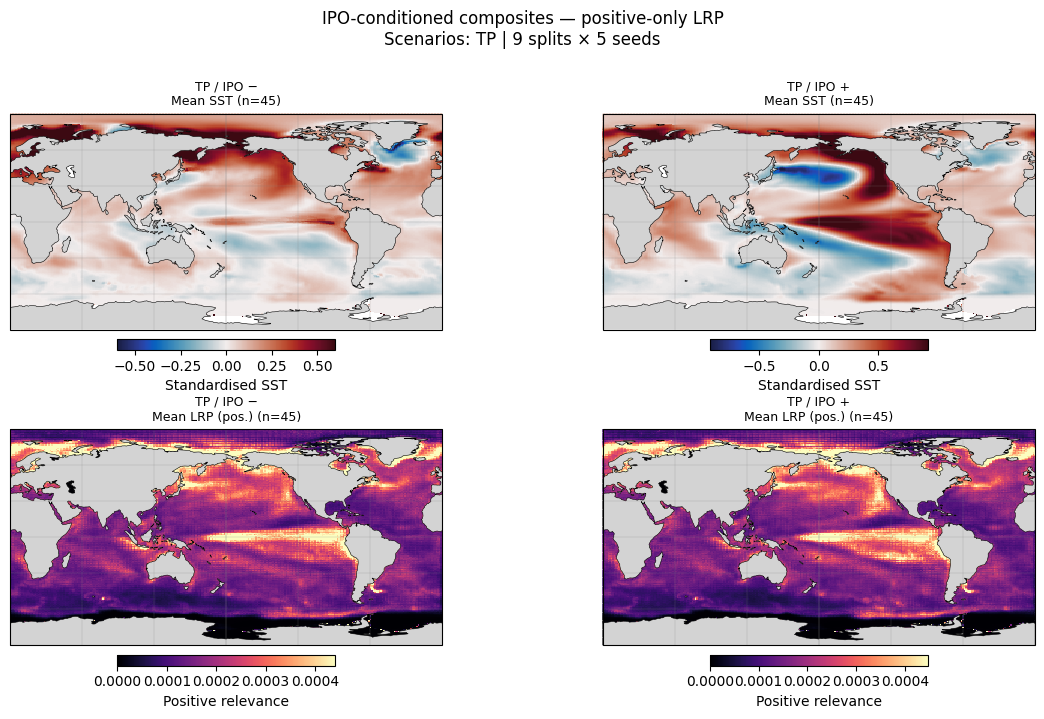

In [11]:
# ── Figure: IPO × positive-only LRP ───────────────────────────────────────────
plot_index_composites('ipo_tr', 'IPO', IPO_PHASES, lrp_positive_only=True)

/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.

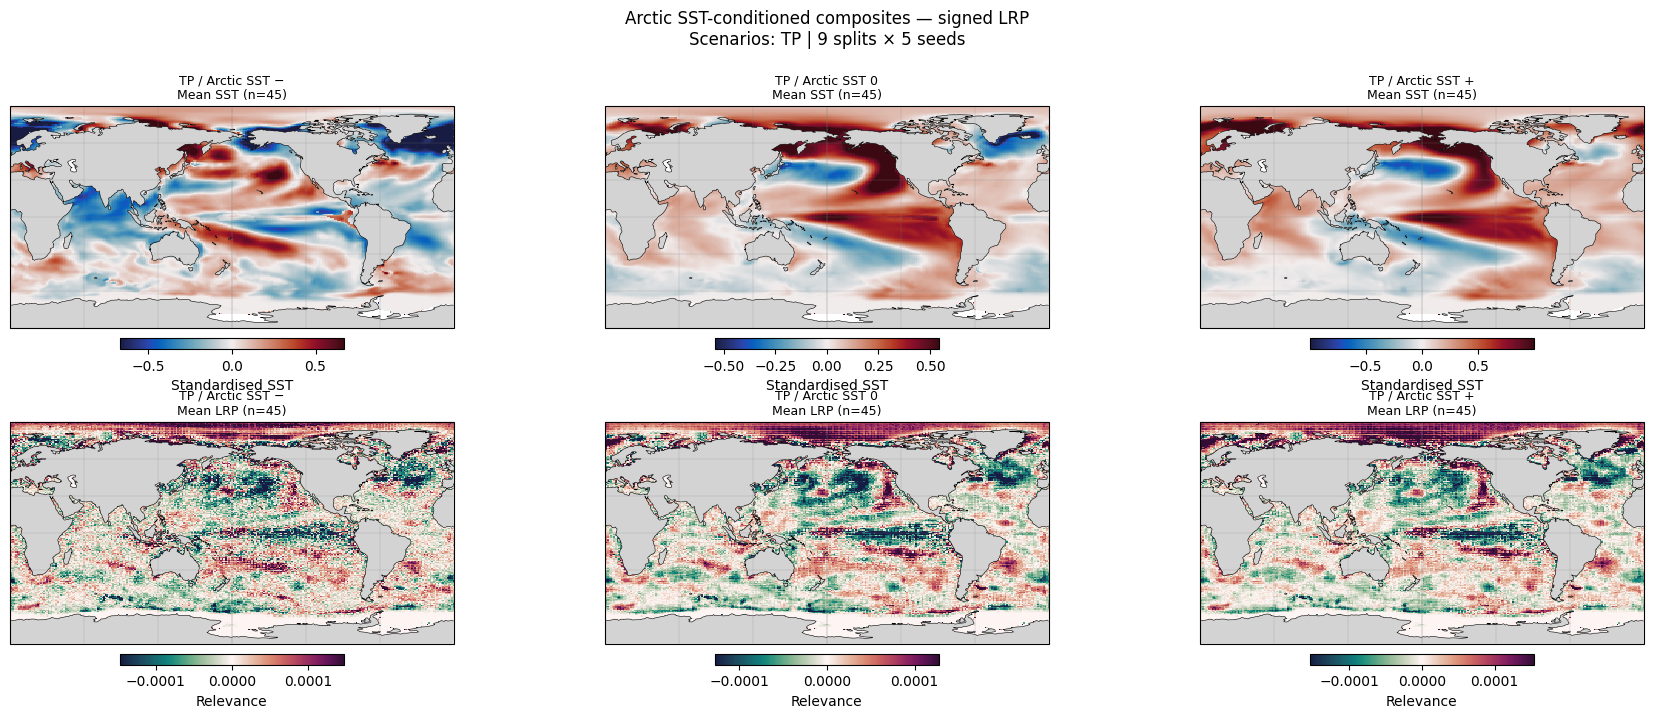

In [12]:
# ── Figure: Arctic SST × signed LRP ───────────────────────────────────────────
plot_index_composites('arctic_tr', 'Arctic SST', ARCTIC_PHASES, lrp_positive_only=False)

/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.nanmean(sst_sub[combined], axis=0))
/tmp/ipykernel_2468436/2446401156.py:82: RuntimeWarning: Mean of empty slice
  comps[sc][plbl]['sst'].append(np.

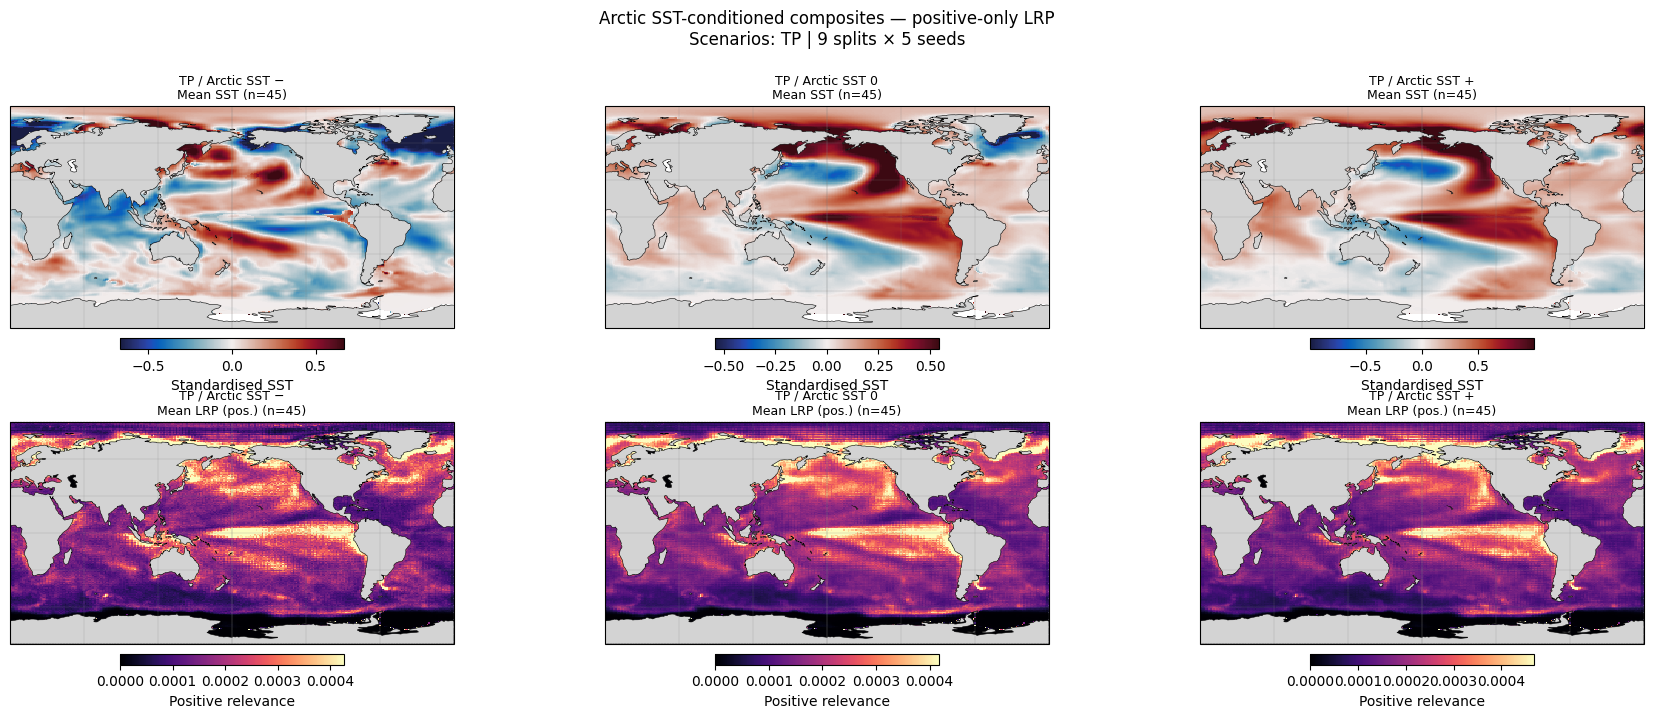

In [13]:
# ── Figure: Arctic SST × positive-only LRP ───────────────────────────────────
plot_index_composites('arctic_tr', 'Arctic SST', ARCTIC_PHASES, lrp_positive_only=True)